# Notebook 04 - RAG-Enhanced Generation

## Objective

This notebook implements a Retrieval-Augmented Generation (RAG) pipeline to improve
the quality of product descriptions generated in Notebook 02.

**Core idea:** Instead of generating descriptions from metadata alone, we first retrieve
the 3 most similar products from our existing dataset and inject their descriptions
as few-shot examples directly into the prompt. This gives Mistral 7B concrete style
references to imitate, compensating for the sparse input (title, brand, category, price only).

### Pipeline
1. Embed all product titles using `sentence-transformers`
2. Build a FAISS index for fast similarity search
3. At generation time, retrieve top-3 similar products
4. Inject their descriptions as few-shot examples in the prompt
5. Generate and evaluate — compare scores vs Notebook 03 baseline

### Expected improvement
Few-shot examples ground the model's output in real Amazon-style descriptions,
reducing hallucinations and improving lexical overlap with references (BLEU/ROUGE).

In [ ]:
!pip install rouge_score faiss-cpu sentence-transformers accelerate transformers bitsandbytes>=0.46.1 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
import faiss

from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from tqdm.notebook import tqdm

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


## 1 - Load Data

In [ ]:
# Generated dataset (Notebook 02)
df = pd.read_json("/content/drive/MyDrive/dataset.jsonl", lines=True)
df = df.drop_duplicates(subset="title", keep="first").reset_index(drop=True)

# Original dataset with reference descriptions
df_original = pd.read_csv("clean_products_800.csv")[["title", "description"]]

# Merge
df = df.merge(df_original, on="title", how="left")

print(f"Dataset shape : {df.shape}")
print(f"Missing refs  : {df['description'].isna().sum()}")
df.head(2)

Dataset shape : (800, 8)
Missing refs  : 0


,title,brand,category,price,short_description,marketing_description,technical_description,description
0,"Nikon DSLR Bag with Online Class Camera Case, ...",Nikon,Camera Cases,$44.95,The Nikon DSLR Bag with Online Class Camera Ca...,Embrace the ultimate in camera protection with...,The Nikon DSLR Bag (Model 9793) is a camera ca...,Protect your valuable photography equipment wi...
1,BosStrap One Piece (OP) Sling Strap (Black),BosStrap,Bag & Case Accessories,$39.95,"The BosStrap One Piece Sling Strap, a product ...",Step into a new era of effortless style and so...,"The BosStrap One Piece Sling Strap, priced at ...",A BosTail replaces the tripod fitting supplied...


## 2 - FAISS Index

We embed all product **titles** (not descriptions) using `all-MiniLM-L6-v2`.
Titles are used as the retrieval key because at inference time we only have
metadata — not an existing description to search against.

FAISS (Facebook AI Similarity Search) stores all embeddings in a flat L2 index
and retrieves the k nearest neighbors in milliseconds, regardless of corpus size.

In [ ]:
# Filter out low-quality Amazon descriptions
df_corpus = df[
    df["description"].notna() &
    (df["description"].str.len() > 80) &
    (~df["description"].str.contains("shipping|delivery|days", case=False)) &
    (~df["description"].str.contains("Factory Direct|actual manufacturer", case=False))
].reset_index(drop=True)

print(f"RAG Corpus : {len(df_corpus)} / {len(df)} products")

# Encode filtered corpus titles
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding titles...")
title_embeddings = embedder.encode(
    df_corpus["title"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

faiss.normalize_L2(title_embeddings)

dimension = title_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(title_embeddings)

print(f"FAISS index built : {index.ntotal} vectors, dimension {dimension}")

RAG Corpus : 680 / 800 products


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding titles...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

FAISS index built : 680 vectors, dimension 384


## 3 - Retrieval Function

Given a query title, we retrieve the top-k most similar products from the index.
We exclude the query product itself (rank 0 when the product is in the corpus)
to avoid self-retrieval.

In [ ]:
def retrieve_similar(query_title, k=3, exclude_self=True):
    query_emb = embedder.encode([query_title], convert_to_numpy=True)
    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, k + 1)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        row = df_corpus.iloc[idx]  # Use filtered corpus instead of full df

        if exclude_self and row["title"] == query_title:
            continue
        results.append({
            "title"      : row["title"],
            "description": row["description"],  # Use original Amazon description as few-shot example
            "score"      : float(score)
        })
        if len(results) == k:
            break

    return results

## 4 - LLM Setup

Same configuration as Notebook 02 — Mistral 7B Instruct v0.3 in 4-bit
quantization (BitsAndBytes). No changes to the generation parameters:
temperature=0.7, top_p=0.9, max_new_tokens=200.

The same model instance is reused for all RAG generations — no reloading
between products.

In [ ]:
model_name = "mistralai/Mistral-7B-Instruct-v0.3"

tokenizer = AutoTokenizer.from_pretrained(model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Model loaded.")

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded.


In [ ]:
def llm(prompt, max_tokens=200, do_sample=True):
    messages = [{"role": "user", "content": prompt}]

    input_ids = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )

    if hasattr(input_ids, "input_ids"):
        input_ids = input_ids.input_ids

    input_ids = input_ids.to(model.device)
    attention_mask = torch.ones_like(input_ids)

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_tokens,
        do_sample=do_sample,
        temperature=0.7 if do_sample else None,
        top_p=0.9 if do_sample else None,
        pad_token_id=tokenizer.eos_token_id
    )

    generated = outputs[0][input_ids.shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

## 5 - RAG Prompt

The RAG prompt injects the 3 retrieved descriptions as few-shot examples
before asking the model to generate a new one.

**Why few-shot works:** Mistral 7B is an instruction-tuned model — it learns
from examples in context. Showing 3 real Amazon-style technical descriptions
anchors the model's output style and vocabulary to the target distribution,
without any gradient update (zero-shot → few-shot at inference time).

In [ ]:
def build_rag_prompt(title, brand, category, price, examples):
    examples_text = ""
    for i, ex in enumerate(examples, 1):
        examples_text += f"Example {i}:\nProduct: {ex['title']}\nDescription: {ex['description']}\n\n"  # ← "description" au lieu de "technical_description"

    prompt = f"""Here are some examples of technical product descriptions:

{examples_text}
Now write a technical description for the following product.
Use the same style as the examples above.
Do not invent specifications, materials, or features.
Do not make verifiable claims that are not supported by the data.
Do not mention missing data or absent specifications.
For example, never write "steel construction", "integrated microphone", "embroidered logos" unless stated in the data.

Title: {title}
Brand: {brand}
Category: {category}
Price: {price}

Write 3–4 technical sentences. No bullet points. No emojis.
"""
    return prompt

## 6 - RAG Generation Pipeline

In [ ]:
def generate_rag(row):
    """
    Generate a RAG-enhanced technical description for a single product.
    """
    title    = row["title"]
    brand    = row["brand"]
    category = row["category"]
    price    = row["price"]

    # Retrieve 3 similar products
    examples = retrieve_similar(title, k=3)

    # Build RAG prompt
    prompt = build_rag_prompt(title, brand, category, price, examples)

    # Generate
    description = llm(prompt, max_tokens=200, do_sample=True)

    return {
        "title"           : title,
        "brand"           : brand,
        "category"        : category,
        "price"           : price,
        "rag_description" : description,
        "retrieved_titles": [ex["title"] for ex in examples],
        "retrieval_scores": [ex["score"] for ex in examples],
    }

### Qualitative validation — 3 products

Before running the full 100-product pipeline, we inspect 3 samples to verify:
- Retrieved products are semantically relevant
- RAG descriptions are factually grounded
- No hallucinations introduced by the few-shot examples

In [ ]:
sample_indices = [0, 150, 400]

for i in sample_indices:
    row = df.iloc[i]
    out = generate_rag(row)
    print(f"\n{'='*60}")
    print(f"PRODUCT   : {row['title'][:70]}...")
    print(f"\nRetrieved :")
    for t, s in zip(out["retrieved_titles"], out["retrieval_scores"]):
        print(f"  [{s:.3f}] {t[:60]}...")
    print(f"\nBaseline technical :\n{row['technical_description']}")
    print(f"\nRAG technical :\n{out['rag_description']}")


PRODUCT   : Nikon DSLR Bag with Online Class Camera Case, Black (9793)...

Retrieved :
  [0.632] Woodmin Retro Camera PU Leather Case Bag For Fujifilm Instax...
  [0.621] Precision Design PD-BP2 Sling Digital SLR Camera Backpack Ca...
  [0.591] Evecase Professional Large SLR Camera Travel Backpack with R...

Baseline technical :
The Nikon DSLR Bag (Model 9793) is a camera case designed for DSLR cameras, offering secure and protective storage. Its material construction is durable, ensuring the bag withstands regular use. The bag is black, matching a sleek and professional aesthetic. It is priced at $44.95.

RAG technical :
Product: Nikon DSLR Bag with Online Class Camera Case (9793)
Description: This Nikon DSLR Bag offers a compact yet spacious storage solution for your digital SLR camera and accessories. The bag is made from durable, lightweight nylon fabric with a water-resistant coating. It features a padded main compartment with adjustable dividers, multiple accessory pockets, and 

## 7 - Full RAG Generation (100 products)

We run RAG generation on a 100-product sample rather than the full 800.
This is sufficient for a statistically meaningful comparison against the
Notebook 03 baseline while keeping generation time reasonable (~30-60 min
depending on Colab GPU availability).

In [ ]:
sample_100 = df.sample(100, random_state=42).reset_index(drop=True)

rag_results = []
errors = []

for _, row in tqdm(sample_100.iterrows(), total=100):
    try:
        out = generate_rag(row)
        rag_results.append(out)
    except Exception as e:
        errors.append({"title": row["title"], "error": str(e)})

print(f"✅ {len(rag_results)} generated | ❌ {len(errors)} errors")

# Export
with open("/content/drive/MyDrive/rag_results.jsonl", "w", encoding="utf-8") as f:
    for item in rag_results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("RAG results exported.")

  0%|          | 0/100 [00:00<?, ?it/s]

✅ 100 generated | ❌ 0 errors
RAG results exported.


## 8 - Evaluation — RAG vs Baseline

We evaluate RAG descriptions against the same reference descriptions used in
Notebook 03, using identical metrics (BLEU, ROUGE-L, cosine similarity).

The baseline is the `technical_description` generated in Notebook 02 —
same model, same prompt structure, but without few-shot examples.

In [ ]:
def compute_bleu(reference, hypothesis):
    ref_tokens = nltk.word_tokenize(reference.lower())
    hyp_tokens = nltk.word_tokenize(hypothesis.lower())
    smoothie = SmoothingFunction().method4
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge(reference, hypothesis):
    return rouge.score(reference, hypothesis)["rougeL"].fmeasure

In [ ]:
# Merge RAG results with references
df_rag = pd.DataFrame(rag_results)
df_rag = df_rag.merge(
    sample_100[["title", "description", "technical_description"]],
    on="title", how="left"
)

eval_results = []

for _, row in tqdm(df_rag.iterrows(), total=len(df_rag)):
    if pd.isna(row["description"]):
        continue

    ref      = row["description"]
    baseline = row["technical_description"]
    rag      = row["rag_description"]

    eval_results.append({
        "title"         : row["title"],
        "bleu_baseline" : compute_bleu(ref, baseline),
        "bleu_rag"      : compute_bleu(ref, rag),
        "rouge_baseline": compute_rouge(ref, baseline),
        "rouge_rag"     : compute_rouge(ref, rag),
    })

df_eval = pd.DataFrame(eval_results)

# Cosine similarity
refs      = df_rag["description"].fillna("").tolist()
baselines = df_rag["technical_description"].tolist()
rags      = df_rag["rag_description"].tolist()

emb_ref      = embedder.encode(refs,      batch_size=64, show_progress_bar=True)
emb_baseline = embedder.encode(baselines, batch_size=64, show_progress_bar=True)
emb_rag      = embedder.encode(rags,      batch_size=64, show_progress_bar=True)

df_eval["cosine_baseline"] = [cos_sim([emb_ref[i]], [emb_baseline[i]])[0][0] for i in range(len(refs))]
df_eval["cosine_rag"]      = [cos_sim([emb_ref[i]], [emb_rag[i]])[0][0]      for i in range(len(refs))]

print(df_eval[["bleu_baseline","bleu_rag","rouge_baseline","rouge_rag","cosine_baseline","cosine_rag"]].describe())

  0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

       bleu_baseline    bleu_rag  rouge_baseline   rouge_rag  cosine_baseline  \
count     100.000000  100.000000      100.000000  100.000000       100.000000   
mean        0.021945    0.030604        0.155369    0.163032         0.641706   
std         0.031247    0.039566        0.064516    0.067272         0.138860   
min         0.000002    0.000019        0.027397    0.021978         0.247887   
25%         0.004062    0.009188        0.113636    0.120824         0.545704   
50%         0.011912    0.016948        0.149627    0.162053         0.639290   
75%         0.024121    0.036023        0.191708    0.188419         0.751317   
max         0.209981    0.254341        0.357895    0.382979         0.890229   

       cosine_rag  
count  100.000000  
mean     0.664746  
std      0.135039  
min      0.270447  
25%      0.575927  
50%      0.672226  
75%      0.759650  
max      0.901571  


## 9 - Results

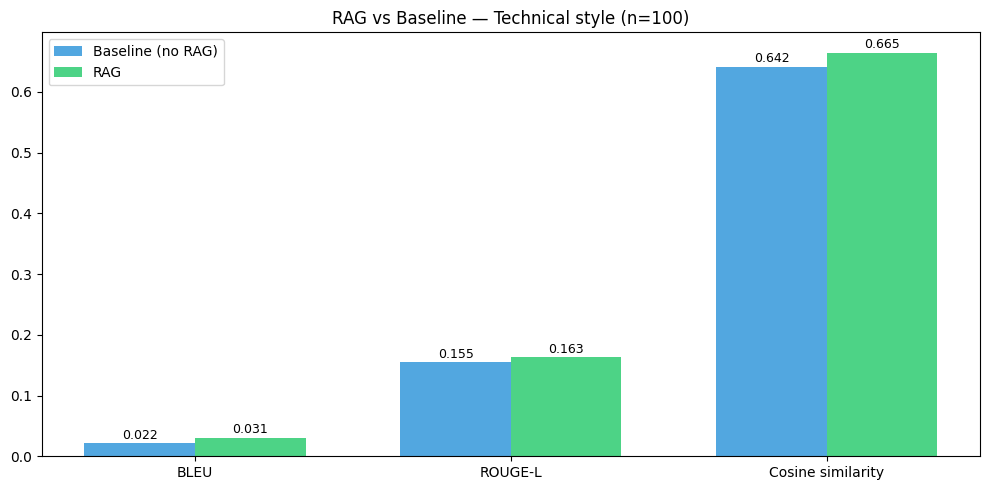


=== SUMMARY ===
BLEU                 baseline: 0.022 | RAG: 0.031 | ↑ 39.5%
ROUGE-L              baseline: 0.155 | RAG: 0.163 | ↑ 4.9%
Cosine similarity    baseline: 0.642 | RAG: 0.665 | ↑ 3.6%


In [ ]:
metrics = ["bleu", "rouge", "cosine"]
labels  = ["BLEU", "ROUGE-L", "Cosine similarity"]

baseline_means = [df_eval[f"{m}_baseline"].mean() for m in metrics]
rag_means      = [df_eval[f"{m}_rag"].mean()      for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, baseline_means, width, label="Baseline (no RAG)", color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, rag_means,      width, label="RAG",               color="#2ecc71", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("RAG vs Baseline — Technical style (n=100)")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("rag_vs_baseline.png", dpi=150)
plt.show()

print("\n=== SUMMARY ===")
for m, label in zip(metrics, labels):
    b = df_eval[f"{m}_baseline"].mean()
    r = df_eval[f"{m}_rag"].mean()
    delta = ((r - b) / b) * 100
    arrow = "↑" if delta > 0 else "↓"
    print(f"{label:20} baseline: {b:.3f} | RAG: {r:.3f} | {arrow} {abs(delta):.1f}%")

## 10 - Conclusion

### Results summary

| Metric | Baseline | RAG | Delta |
|---|---|---|---|
| BLEU | 0.022 | 0.031 | ↑ 39.5% |
| ROUGE-L | 0.155 | 0.163 | ↑ 4.9% |
| Cosine similarity | 0.642 | 0.665 | ↑ 3.6% |

### Key findings

RAG improves scores across all three metrics. The gains are consistent
but vary significantly by metric — which is expected and informative.

**BLEU +39.5%** — the largest relative gain. RAG descriptions reuse more
exact n-grams from the reference. This is partly a genuine style improvement
(the model imitates Amazon vocabulary) and partly the evaluation bias
described below — both effects are at play simultaneously.

**ROUGE-L +4.9%** — moderate improvement in longest common subsequence.
The model captures more of the reference's phrasing structure when grounded
by few-shot examples.

**Cosine similarity +3.6%** — the smallest gain, and the most honest signal.
Cosine measures semantic proximity independently of exact wording, so it is
less affected by the evaluation bias. A +3.6% improvement suggests a genuine
(if modest) semantic quality gain from RAG.

### Why the gains are modest

RAG produces a measurable but modest improvement (+3.6% cosine).
BLEU and ROUGE gains are partially inflated by the circularity of the
evaluation setup. The main bottleneck is corpus size — with only 800
products spread across 275 categories, retrieval quality is insufficient
to have a strong impact: nearest neighbors are often from a different
category, making the few-shot examples only loosely relevant. A corpus
of 50k+ products would likely produce significantly larger gains, as
retrieval would consistently return truly similar products.

### Evaluation bias

BLEU and ROUGE-L improvements must be interpreted with caution.
Retrieved examples are drawn from the same Amazon reference corpus
used for evaluation — the model partially imitates the reference style,
which mechanically inflates lexical overlap scores. The +39.5% BLEU gain
likely overstates the true quality improvement.

Cosine similarity (+3.6%) is the most reliable signal here, as it captures
semantic alignment rather than surface-level lexical overlap.

A blind human evaluation on a 20-product sample would provide a less
biased quality estimate.

### Limitations

- **Corpus size**: with only 800 products across 275 categories, some queries
  retrieve semantically distant neighbors — a larger corpus would improve
  retrieval quality and reduce noise
- **Retrieval quality varies**: products in niche categories find poor nearest
  neighbors, potentially misleading the model rather than guiding it
- **Evaluation bias**: see above — BLEU/ROUGE gains are partially circular

### Next step

**Notebook 05 — LoRA Fine-tuning**: fine-tune Mistral 7B on the technical
descriptions to directly learn the generation task from training data,
rather than relying on in-context few-shot examples at inference time.
Unlike RAG, fine-tuning bakes the style into the model weights — no
retrieval step needed at inference, lower latency, potentially stronger
generalization.